# Лабораторная работа №2: Прогнозирование с помощью линейной нейронной сети

**Дисциплина:** Генетические и эволюционные вычисления

**Тема:** Прогнозирование значений процесса с помощью линейной нейронной сети

---

### Постановка задачи

Дан сигнал $x(t) = \sin(k \cdot t)$ на интервале $[0, 4\pi]$ с шагом дискретизации $\Delta t = 0.1$ с.

Необходимо построить линейную нейронную сеть, которая по $k$ предыдущим значениям сигнала прогнозирует следующее значение.

### Метод решения

Линейная нейронная сеть реализуется через решение системы линейных уравнений методом наименьших квадратов:

$$\mathbf{W} = \mathbf{T} \cdot \mathbf{P}^{+}$$

где $\mathbf{P}^{+}$ — псевдообратная матрица Мура-Пенроуза, $\mathbf{T}$ — вектор целевых значений, $\mathbf{P}$ — матрица входных данных (каждый столбец содержит $k$ последовательных значений сигнала).

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import os

os.makedirs("outputs", exist_ok=True)

%matplotlib inline
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["font.size"] = 12

## Генерация сигнала

Генерируем сигнал $x(t) = \sin(2t)$ на интервале $[0, 4\pi]$ с шагом $\Delta t = 0.1$.

Количество отсчётов: 126
Интервал: [0.0, 12.5]
Частотный параметр: 2


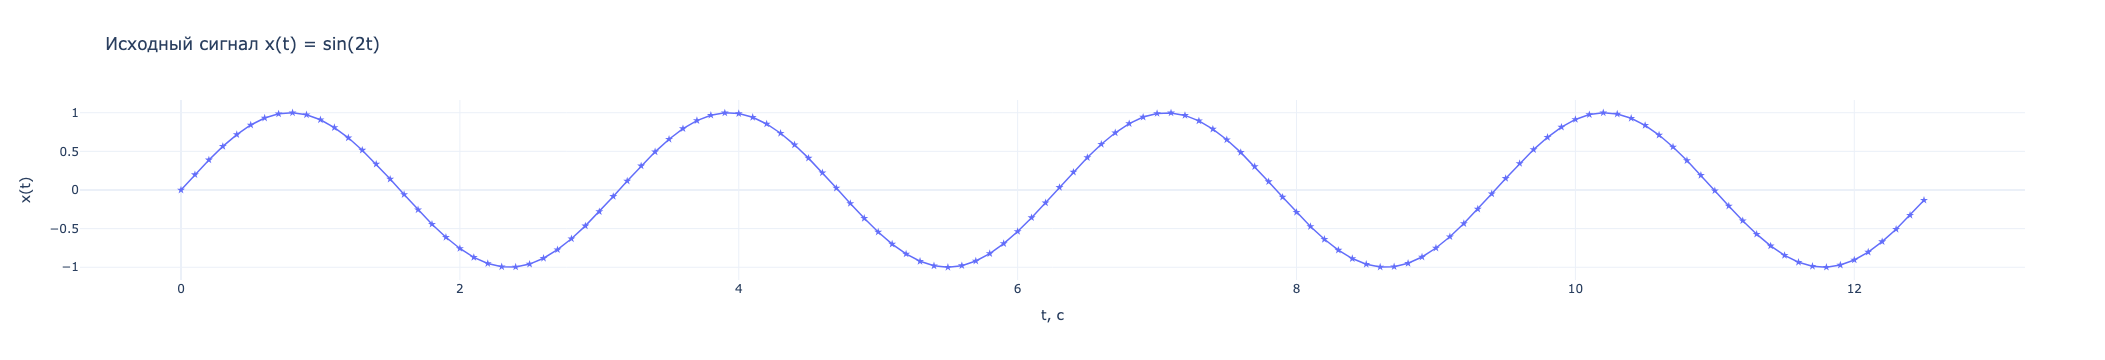

In [2]:
dt = 0.1
freq = 2
t = np.arange(0, 4 * np.pi, dt)
x = np.sin(freq * t)

print(f"Количество отсчётов: {len(t)}")
print(f"Интервал: [{t[0]:.1f}, {t[-1]:.1f}]")
print(f"Частотный параметр: {freq}")

fig = go.Figure()
fig.add_trace(go.Scatter(
    x=t, y=x,
    mode="lines+markers",
    marker=dict(symbol="star", size=6),
    line=dict(width=1.5),
    name="x(t) = sin(2t)"
))
fig.update_layout(
    title="Исходный сигнал x(t) = sin(2t)",
    xaxis_title="t, с",
    yaxis_title="x(t)",
    template="plotly_white",
    hovermode="x unified"
)
fig.write_html("outputs/signal.html")
fig.show()

## Построение линейной нейронной сети

Формируем матрицу входов $\mathbf{P}$ и вектор целевых значений $\mathbf{T}$:

- Каждый столбец матрицы $\mathbf{P}$ содержит $k$ последовательных значений сигнала: $[x_i, x_{i+1}, \dots, x_{i+k-1}]^T$
- Соответствующий элемент вектора $\mathbf{T}$ — следующее значение сигнала: $x_{i+k}$

Весовая матрица (вектор) вычисляется через псевдообратную матрицу:

$$\mathbf{W} = \mathbf{T} \cdot \mathbf{P}^{+}$$

In [3]:
def build_linear_nn(signal, k):
    """Построение линейной нейронной сети для прогнозирования.

    Args:
        signal: одномерный массив значений сигнала
        k: количество предыдущих значений (размер входного окна)

    Returns:
        W: весовой вектор (1 x k)
        P: матрица входов (k x N-k)
        T: вектор целевых значений (1 x N-k)
    """
    n = len(signal)
    num_samples = n - k

    P = np.zeros((k, num_samples))
    for i in range(num_samples):
        P[:, i] = signal[i:i + k]

    T = signal[k:].reshape(1, -1)

    P_pinv = np.linalg.pinv(P)
    W = T @ P_pinv

    return W, P, T


def predict(W, P):
    """Прогноз выхода сети."""
    return W @ P


k = 5
W, P, T = build_linear_nn(x, k)

print(f"Параметр k (размер окна): {k}")
print(f"Размер матрицы P: {P.shape}")
print(f"Размер вектора T: {T.shape}")
print(f"Размер вектора W: {W.shape}")
print(f"\nВесовой вектор W:")
print(np.round(W, 6))

Параметр k (размер окна): 5
Размер матрицы P: (5, 121)
Размер вектора T: (1, 121)
Размер вектора W: (1, 5)

Весовой вектор W:
[[-0.410636 -0.118311  0.17873   0.468647  0.739879]]


## Моделирование и результаты

Получаем прогнозируемый сигнал $y$ и сравниваем его с исходным. Строим графики наложения сигналов и ошибки прогнозирования $e = x - y$.

MSE = 6.51e-31
MAE = 5.59e-16


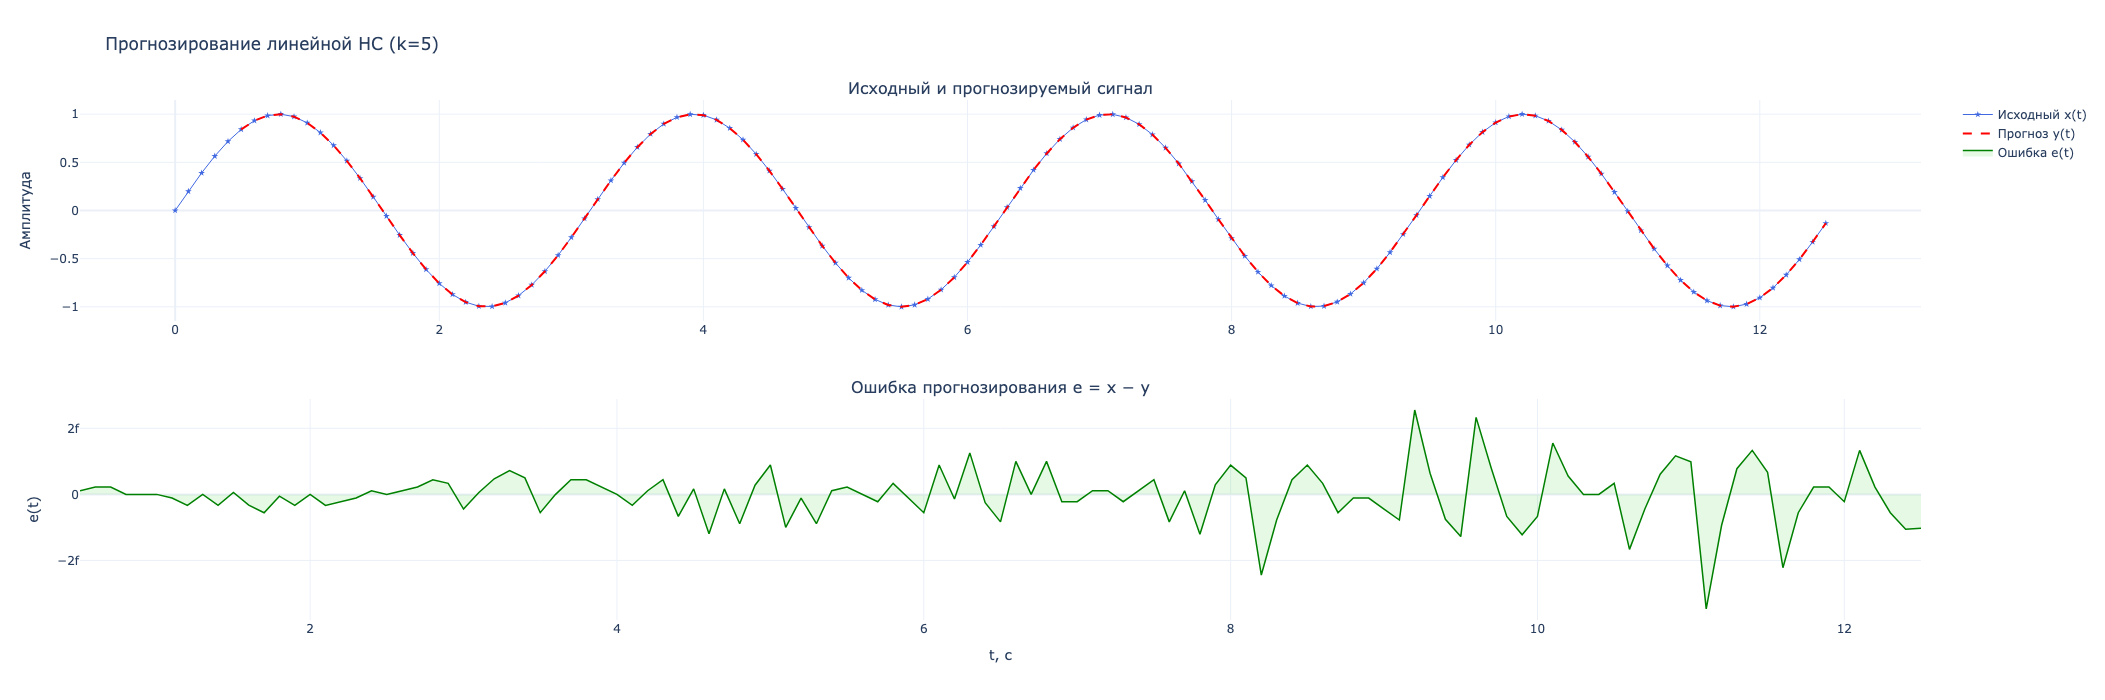

In [4]:
y = predict(W, P).flatten()
t_pred = t[k:]
x_pred = x[k:]
error = x_pred - y

mse = np.mean(error ** 2)
mae = np.mean(np.abs(error))
print(f"MSE = {mse:.2e}")
print(f"MAE = {mae:.2e}")

fig = make_subplots(
    rows=2, cols=1,
    subplot_titles=("Исходный и прогнозируемый сигнал", "Ошибка прогнозирования e = x − y"),
    vertical_spacing=0.15
)

fig.add_trace(go.Scatter(
    x=t, y=x,
    mode="lines+markers",
    marker=dict(symbol="star", size=5, color="royalblue"),
    line=dict(width=1, color="royalblue"),
    name="Исходный x(t)"
), row=1, col=1)

fig.add_trace(go.Scatter(
    x=t_pred, y=y,
    mode="lines",
    line=dict(width=2, color="red", dash="dash"),
    name="Прогноз y(t)"
), row=1, col=1)

fig.add_trace(go.Scatter(
    x=t_pred, y=error,
    mode="lines",
    line=dict(width=1.5, color="green"),
    name="Ошибка e(t)",
    fill="tozeroy",
    fillcolor="rgba(0,200,0,0.1)"
), row=2, col=1)

fig.update_xaxes(title_text="t, с", row=2, col=1)
fig.update_yaxes(title_text="Амплитуда", row=1, col=1)
fig.update_yaxes(title_text="e(t)", row=2, col=1)

fig.update_layout(
    height=700,
    template="plotly_white",
    title_text=f"Прогнозирование линейной НС (k={k})",
    hovermode="x unified"
)

fig.write_html("outputs/prediction_k5.html")
fig.show()

## Анализ влияния параметров

### Влияние параметра k (размер входного окна)

Исследуем, как число предыдущих значений $k$ (от 2 до 10) влияет на точность прогнозирования.

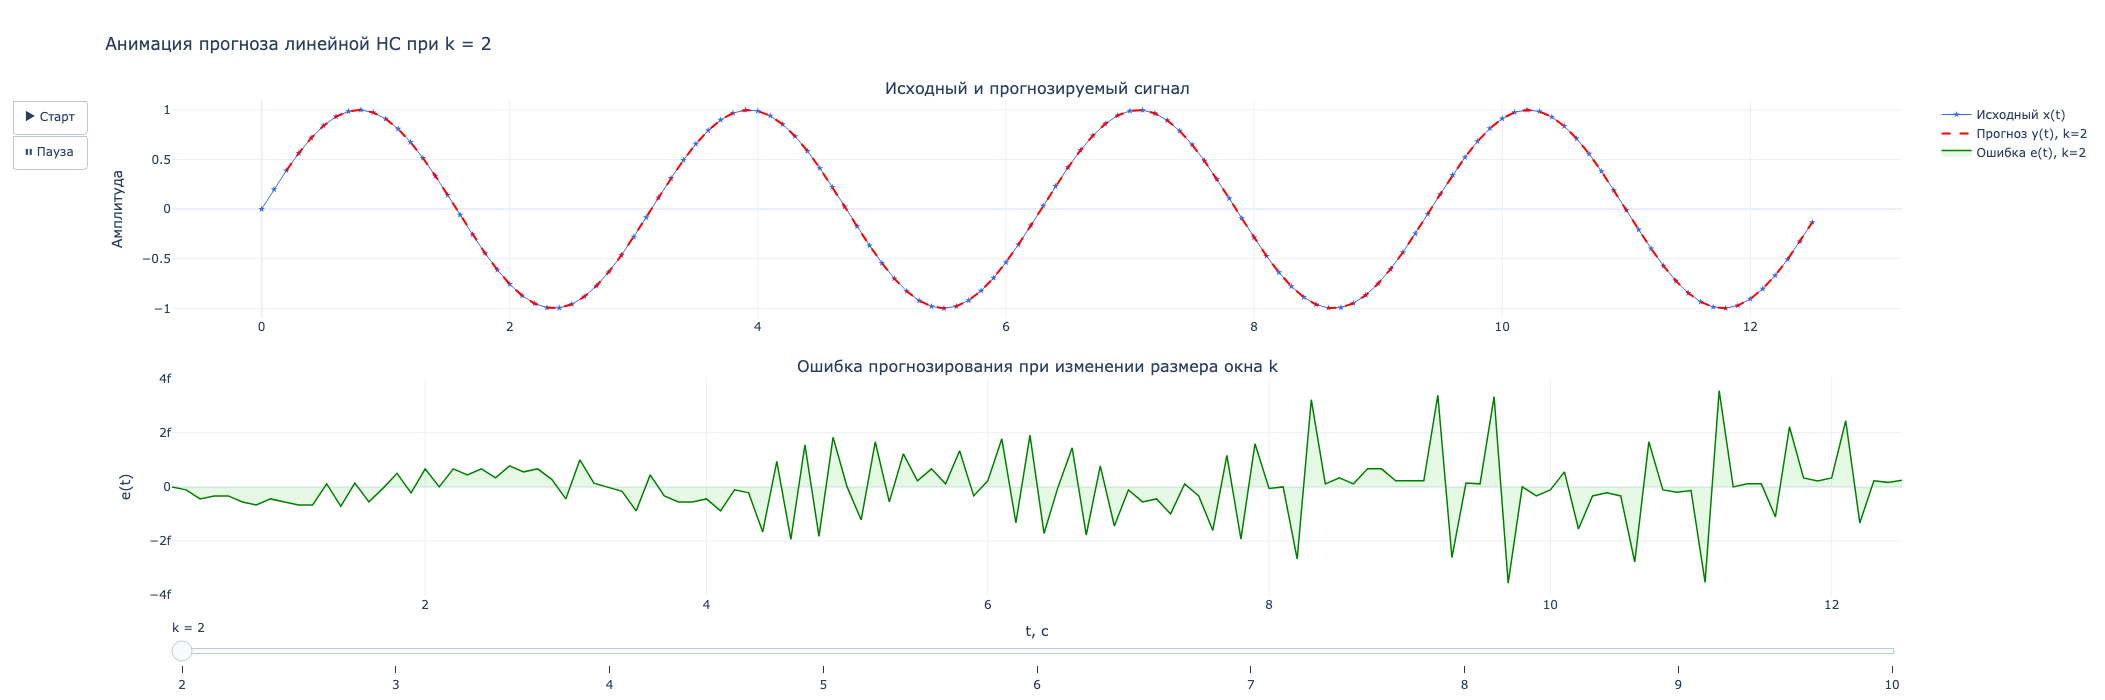


  k  |    MSE       |    MAE
-----|--------------|-------------
  2  |  1.459002e-30  |  8.269735e-16
  3  |  1.434970e-30  |  9.987353e-16
  4  |  8.286700e-31  |  6.671576e-16
  5  |  6.505628e-31  |  5.589537e-16
  6  |  5.027201e-31  |  5.135360e-16
  7  |  4.865146e-31  |  5.114227e-16
  8  |  6.410040e-31  |  6.525353e-16
  9  |  4.591443e-31  |  5.075771e-16
  10  |  3.456210e-31  |  4.232127e-16


In [5]:
k_values = list(range(2, 11))
mse_by_k = []
mae_by_k = []
predictions_by_k = []
errors_by_k = []

y_min = min(x.min(), -0.25)
y_max = max(x.max(), 0.25)
error_bound = 0.0

for k_val in k_values:
    W_k, P_k, T_k = build_linear_nn(x, k_val)
    y_k = predict(W_k, P_k).flatten()
    e_k = x[k_val:] - y_k

    mse_k = np.mean(e_k ** 2)
    mae_k = np.mean(np.abs(e_k))
    mse_by_k.append(mse_k)
    mae_by_k.append(mae_k)
    predictions_by_k.append((t[k_val:], y_k))
    errors_by_k.append((t[k_val:], e_k))
    error_bound = max(error_bound, np.max(np.abs(e_k)))

fig_k = make_subplots(
    rows=2, cols=1,
    subplot_titles=(
        'Исходный и прогнозируемый сигнал',
        'Ошибка прогнозирования при изменении размера окна k'
    ),
    vertical_spacing=0.12
)

fig_k.add_trace(go.Scatter(
    x=t, y=x,
    mode='lines+markers',
    marker=dict(symbol='star', size=5, color='royalblue'),
    line=dict(width=1, color='royalblue'),
    name='Исходный x(t)'
), row=1, col=1)

initial_t_pred, initial_y_pred = predictions_by_k[0]
initial_t_err, initial_err = errors_by_k[0]

fig_k.add_trace(go.Scatter(
    x=initial_t_pred, y=initial_y_pred,
    mode='lines',
    line=dict(width=2, color='red', dash='dash'),
    name=f'Прогноз y(t), k={k_values[0]}'
), row=1, col=1)

fig_k.add_trace(go.Scatter(
    x=initial_t_err, y=initial_err,
    mode='lines',
    line=dict(width=1.5, color='green'),
    name=f'Ошибка e(t), k={k_values[0]}',
    fill='tozeroy',
    fillcolor='rgba(0,200,0,0.1)'
), row=2, col=1)

frames_k = []
for idx, k_val in enumerate(k_values):
    t_pred_k, y_pred_k = predictions_by_k[idx]
    t_err_k, err_k = errors_by_k[idx]
    frames_k.append(go.Frame(
        data=[
            go.Scatter(x=t_pred_k, y=y_pred_k, name=f'Прогноз y(t), k={k_val}'),
            go.Scatter(x=t_err_k, y=err_k, name=f'Ошибка e(t), k={k_val}'),
        ],
        traces=[1, 2],
        name=str(k_val),
        layout=go.Layout(title_text=f'Анимация прогноза линейной НС при k = {k_val}')
    ))

fig_k.frames = frames_k
fig_k.update_xaxes(title_text='t, c', row=2, col=1)
fig_k.update_yaxes(title_text='Амплитуда', row=1, col=1, range=[y_min - 0.1, y_max + 0.1])
fig_k.update_yaxes(title_text='e(t)', row=2, col=1, range=[-error_bound * 1.1, error_bound * 1.1])

fig_k.update_layout(
    height=700,
    template='plotly_white',
    title_text=f'Анимация прогноза линейной НС при k = {k_values[0]}',
    hovermode='x unified',
    updatemenus=[dict(
        type='buttons',
        showactive=False,
        buttons=[
            dict(label='▶ Старт', method='animate', args=[None, dict(frame=dict(duration=900, redraw=True), fromcurrent=True)]),
            dict(label='⏸ Пауза', method='animate', args=[[None], dict(frame=dict(duration=0, redraw=False), mode='immediate')]),
        ],
    )],
    sliders=[dict(
        active=0,
        currentvalue=dict(prefix='k = '),
        steps=[
            dict(
                method='animate',
                args=[[str(k_val)], dict(frame=dict(duration=0, redraw=True), mode='immediate')],
                label=str(k_val)
            )
            for k_val in k_values
        ]
    )]
)
fig_k.write_html('outputs/error_by_k.html')
fig_k.show()

print("\n  k  |    MSE       |    MAE")
print("-----|--------------|-------------")
for k_val, m, a in zip(k_values, mse_by_k, mae_by_k):
    print(f"  {k_val}  |  {m:.6e}  |  {a:.6e}")

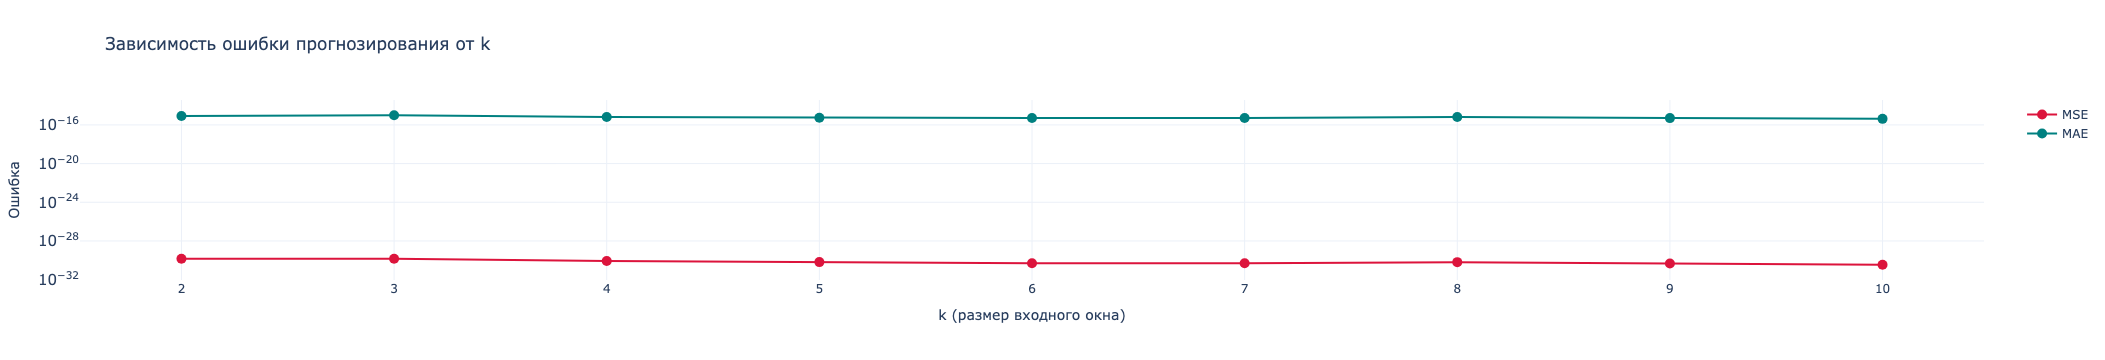

In [6]:
fig_mse = go.Figure()

fig_mse.add_trace(go.Scatter(
    x=k_values, y=mse_by_k,
    mode="lines+markers",
    marker=dict(size=10, color="crimson"),
    line=dict(width=2, color="crimson"),
    name="MSE"
))

fig_mse.add_trace(go.Scatter(
    x=k_values, y=mae_by_k,
    mode="lines+markers",
    marker=dict(size=10, color="teal"),
    line=dict(width=2, color="teal"),
    name="MAE"
))

fig_mse.update_layout(
    title="Зависимость ошибки прогнозирования от k",
    xaxis_title="k (размер входного окна)",
    yaxis_title="Ошибка",
    yaxis_type="log",
    template="plotly_white",
    xaxis=dict(dtick=1)
)

fig_mse.write_html("outputs/mse_vs_k.html")
fig_mse.show()

### Влияние частоты сигнала

Исследуем, как частотный параметр $\omega$ в $x(t) = \sin(\omega t)$ влияет на точность прогнозирования при фиксированном $k = 5$.

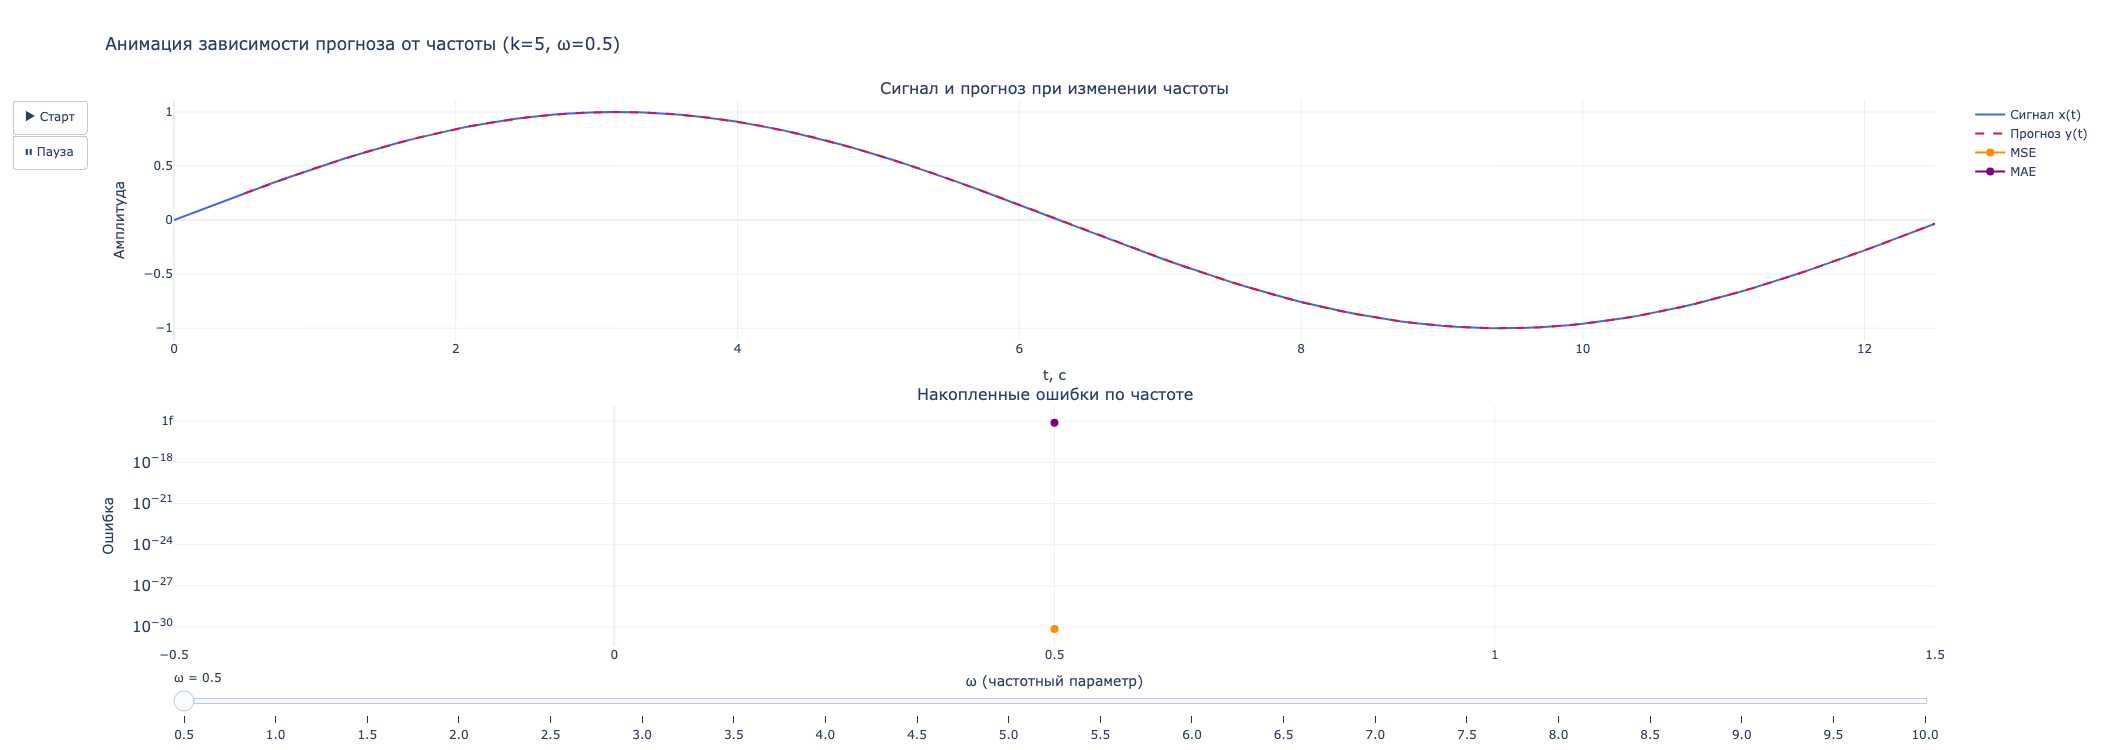


   ω   |    MSE       |    MAE
-------|--------------|-------------
   0.5 |  7.161609e-31  |  7.720666e-16
   1.0 |  2.206328e-31  |  3.571523e-16
   1.5 |  1.001452e-30  |  8.249542e-16
   2.0 |  6.505628e-31  |  5.589537e-16
   2.5 |  1.683998e-30  |  8.575412e-16
   3.0 |  1.864360e-30  |  9.795023e-16
   3.5 |  1.818008e-05  |  3.822068e-03
   4.0 |  1.652699e-30  |  9.528506e-16
   4.5 |  1.140251e-05  |  3.044908e-03
   5.0 |  1.931284e-05  |  3.957947e-03
   5.5 |  1.119210e-05  |  3.014758e-03
   6.0 |  1.431314e-05  |  3.410528e-03
   6.5 |  4.490455e-06  |  1.907319e-03
   7.0 |  2.477519e-06  |  1.419728e-03
   7.5 |  6.793638e-07  |  7.409529e-04
   8.0 |  2.974440e-06  |  1.549445e-03
   8.5 |  1.086055e-06  |  9.374234e-04
   9.0 |  4.196854e-06  |  1.849689e-03
   9.5 |  1.573294e-06  |  1.130046e-03
  10.0 |  1.114717e-06  |  9.499288e-04


In [7]:
freq_values = np.arange(0.5, 10.5, 0.5)
k_fixed = 5
mse_by_freq = []
mae_by_freq = []
signals_by_freq = []
predictions_by_freq = []

for f in freq_values:
    x_f = np.sin(f * t)
    W_f, P_f, T_f = build_linear_nn(x_f, k_fixed)
    y_f = predict(W_f, P_f).flatten()
    e_f = x_f[k_fixed:] - y_f
    mse_by_freq.append(np.mean(e_f ** 2))
    mae_by_freq.append(np.mean(np.abs(e_f)))
    signals_by_freq.append(x_f)
    predictions_by_freq.append(y_f)

fig_freq = make_subplots(
    rows=2, cols=1,
    subplot_titles=(
        'Сигнал и прогноз при изменении частоты',
        'Накопленные ошибки по частоте'
    ),
    vertical_spacing=0.12
)

fig_freq.add_trace(go.Scatter(
    x=t, y=signals_by_freq[0],
    mode='lines',
    line=dict(width=2, color='royalblue'),
    name='Сигнал x(t)'
), row=1, col=1)

fig_freq.add_trace(go.Scatter(
    x=t[k_fixed:], y=predictions_by_freq[0],
    mode='lines',
    line=dict(width=2, color='crimson', dash='dash'),
    name='Прогноз y(t)'
), row=1, col=1)

fig_freq.add_trace(go.Scatter(
    x=freq_values[:1], y=mse_by_freq[:1],
    mode='lines+markers',
    marker=dict(size=8, color='darkorange'),
    line=dict(width=2, color='darkorange'),
    name='MSE'
), row=2, col=1)

fig_freq.add_trace(go.Scatter(
    x=freq_values[:1], y=mae_by_freq[:1],
    mode='lines+markers',
    marker=dict(size=8, color='purple'),
    line=dict(width=2, color='purple'),
    name='MAE'
), row=2, col=1)

frames_freq = []
for idx, f in enumerate(freq_values):
    frames_freq.append(go.Frame(
        data=[
            go.Scatter(x=t, y=signals_by_freq[idx]),
            go.Scatter(x=t[k_fixed:], y=predictions_by_freq[idx]),
            go.Scatter(x=freq_values[:idx + 1], y=mse_by_freq[:idx + 1]),
            go.Scatter(x=freq_values[:idx + 1], y=mae_by_freq[:idx + 1]),
        ],
        traces=[0, 1, 2, 3],
        name=f'{f:.1f}',
        layout=go.Layout(title=f'Анимация зависимости прогноза от частоты (k={k_fixed}, ω={f:.1f})')
    ))

fig_freq.frames = frames_freq
fig_freq.update_xaxes(title_text='t, c', row=1, col=1)
fig_freq.update_xaxes(title_text='ω (частотный параметр)', row=2, col=1)
fig_freq.update_yaxes(title_text='Амплитуда', row=1, col=1)
fig_freq.update_yaxes(title_text='Ошибка', row=2, col=1, type='log')

fig_freq.update_layout(
    title=f'Анимация зависимости прогноза от частоты (k={k_fixed}, ω={freq_values[0]:.1f})',
    template='plotly_white',
    height=750,
    updatemenus=[dict(
        type='buttons',
        showactive=False,
        buttons=[
            dict(label='▶ Старт', method='animate', args=[None, dict(frame=dict(duration=800, redraw=True), fromcurrent=True)]),
            dict(label='⏸ Пауза', method='animate', args=[[None], dict(frame=dict(duration=0, redraw=False), mode='immediate')]),
        ]
    )],
    sliders=[dict(
        active=0,
        currentvalue=dict(prefix='ω = '),
        steps=[
            dict(
                method='animate',
                args=[[f'{freq:.1f}'], dict(frame=dict(duration=0, redraw=True), mode='immediate')],
                label=f'{freq:.1f}'
            )
            for freq in freq_values
        ]
    )]
)

fig_freq.write_html("outputs/mse_vs_freq.html")
fig_freq.show()

print("\n   ω   |    MSE       |    MAE")
print("-------|--------------|-------------")
for f, m, a in zip(freq_values, mse_by_freq, mae_by_freq):
    print(f"  {f:4.1f} |  {m:.6e}  |  {a:.6e}")

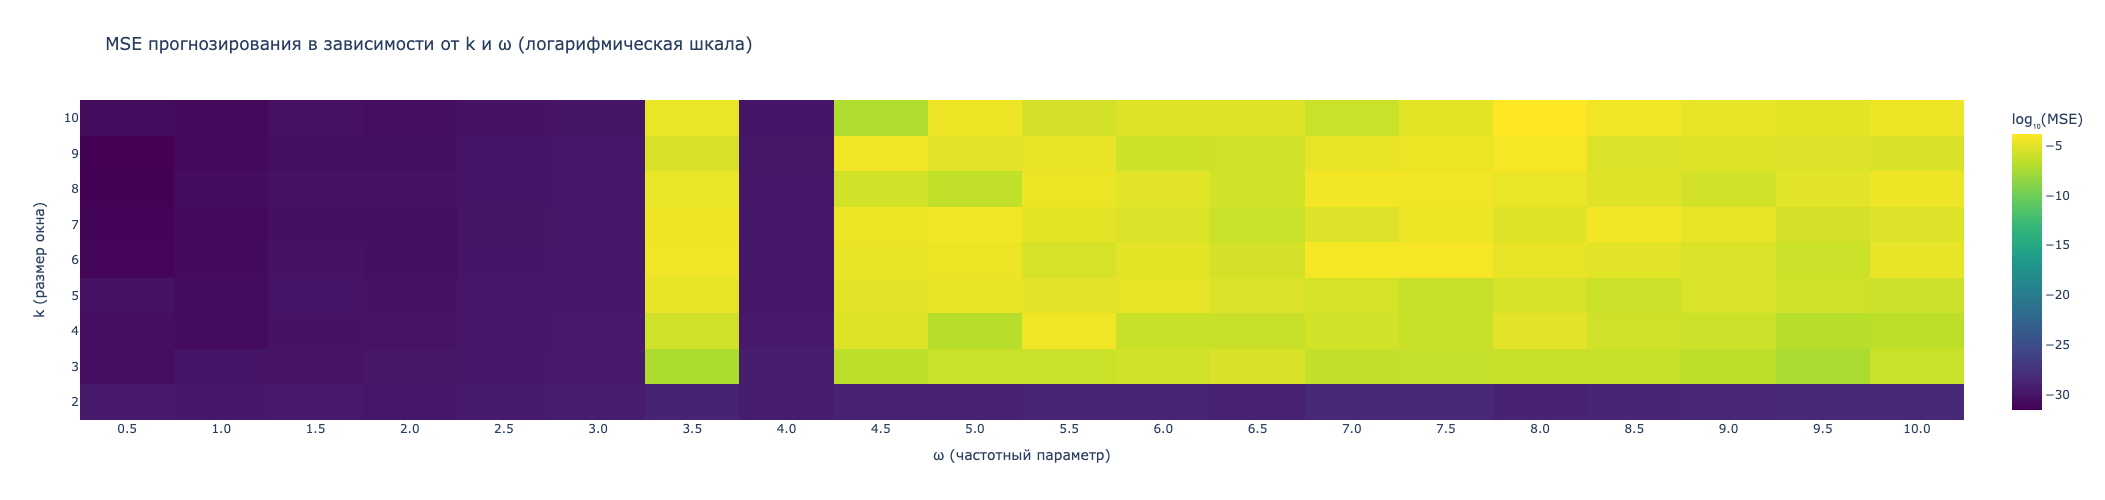

In [8]:
fig_heatmap_data = np.zeros((len(k_values), len(freq_values)))

for i, k_val in enumerate(k_values):
    for j, f in enumerate(freq_values):
        x_hm = np.sin(f * t)
        W_hm, P_hm, _ = build_linear_nn(x_hm, k_val)
        y_hm = predict(W_hm, P_hm).flatten()
        e_hm = x_hm[k_val:] - y_hm
        fig_heatmap_data[i, j] = np.mean(e_hm ** 2)

fig_hm = go.Figure(data=go.Heatmap(
    z=np.log10(fig_heatmap_data + 1e-32),
    x=[f"{f:.1f}" for f in freq_values],
    y=[str(k_val) for k_val in k_values],
    colorscale="Viridis",
    colorbar=dict(title="log₁₀(MSE)"),
    hovertemplate="ω=%{x}<br>k=%{y}<br>log₁₀(MSE)=%{z:.2f}<extra></extra>"
))

fig_hm.update_layout(
    title="MSE прогнозирования в зависимости от k и ω (логарифмическая шкала)",
    xaxis_title="ω (частотный параметр)",
    yaxis_title="k (размер окна)",
    template="plotly_white",
    height=500
)

fig_hm.write_html("outputs/mse_heatmap.html")
fig_hm.show()

## Выводы

1. **Линейная нейронная сеть** на основе псевдообратной матрицы эффективно прогнозирует значения синусоидального сигнала по $k$ предыдущим отсчётам. При достаточном числе входов ошибка прогноза стремится к машинной точности.

2. **Влияние параметра $k$:** с увеличением числа предыдущих значений $k$ точность прогнозирования, как правило, возрастает. Уже при $k \geq 3$ линейная сеть хорошо аппроксимирует синусоидальный сигнал. Дальнейшее увеличение $k$ не обязательно приводит к значительному улучшению, поскольку синусоида полностью определяется двумя предыдущими значениями.

3. **Влияние частоты сигнала:** при увеличении частоты $\omega$ (при фиксированном шаге дискретизации $\Delta t$) ошибка прогнозирования может возрастать. Это связано с тем, что при высоких частотах на один период приходится меньше отсчётов, и линейная аппроксимация становится менее точной.

4. **Тепловая карта** наглядно демонстрирует совместное влияние обоих параметров: оптимальная область — низкие частоты и достаточное число входов.